[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/spirosChv/neuro208-tutorials/blob/main/Practical_NEURON_and_DendroTweaks/NEURON_tutorial_2.ipynb)

# NEURON: Morphology, Channels and Synapses

In [1]:
!pip install neuron --quiet

In [2]:
import neuron
from neuron import h
import os, shutil

In [3]:
h.load_file('stdrun.hoc')

1.0

In [4]:
!rm -rf data

In [5]:
# @markdown Create data directories
path_to_mod = os.path.join(os.getcwd(), 'data', 'mod')
path_to_swc = os.path.join(os.getcwd(), 'data', 'swc')

if not os.path.exists(path_to_mod):
    os.makedirs(path_to_mod)
if not os.path.exists(path_to_swc):
    os.makedirs(path_to_swc)

## MOD files

In [6]:
# @markdown MOD file for a sodium (Na) channel
with open(os.path.join(path_to_mod, 'Nav.mod'), 'w') as f:
    f.write("""TITLE standardized sodium channel

COMMENT
Standardized and templated by DendroTweaks.
This NMODL file defines a model for a na ion channel.
ENDCOMMENT

NEURON {
    SUFFIX Nav
    USEION na READ ena WRITE ina
    RANGE gbar, i, gbar, vhalf_m, sigma_m, k_m, delta_m, tau0_m, vhalf_h, sigma_h, k_h, delta_h, tau0_h
}

UNITS {
    (mA) = (milliamp)
	(mV) = (millivolt)
	(S)  = (siemens)
	(um) = (micron)
}

PARAMETER {
    gbar    = 0.0 (S/cm2)
    vhalf_m = -32.571 (mV)
    sigma_m = 9.8 (mV)
    k_m     = 1.882 (1/ms)
    delta_m = 0.541 (1)
    tau0_m  = 0.065 (ms)
    vhalf_h = -60.0 (mV)
    sigma_h = -6.2 (mV)
    k_h     = 0.018 (1/ms)
    delta_h = 0.395 (1)
    tau0_h  = 0.797 (ms)
    q10     = 2.3 (1)
    temp    = 23 (degC)
}

ASSIGNED {
    v        (mV)     : membrane voltage
    i        (mA/cm2) : current density
    ina      (mA/cm2) : current density of na ion
    gna      (S/cm2)  : conductance of na ion
    ena      (mV)     : reversal potential of na ion

    m_inf    (1)      : steady state value of m
    tau_m    (ms)     : time constant of m

    h_inf    (1)      : steady state value of h
    tau_h    (ms)     : time constant of h

    tadj     (1)      : temperature adjustment factor
    celsius  (degC)   : simulation temperature in celsius
}

STATE { m h }

BREAKPOINT {
    SOLVE states METHOD cnexp
    gna = tadj * gbar * pow(m, 3) * h
    i = gna * (v - ena)
    ina = i
}

DERIVATIVE states {
    rates(v)
    m' = (m_inf - m) / tau_m
    h' = (h_inf - h) / tau_h
}

INITIAL {
    tadj = q10^((celsius - temp)/10(degC))
    rates(v)
    m = m_inf
    h = h_inf
}

FUNCTION alpha_prime(v (mV), k (1/ms), delta (1), vhalf (mV), sigma (mV)) (1/ms) {
    alpha_prime = k * exp(delta * (v - vhalf) / sigma)
}

FUNCTION beta_prime(v (mV), k (1/ms), delta (1), vhalf (mV), sigma (mV)) (1/ms) {
    beta_prime = k * exp(-(1 - delta) * (v - vhalf) / sigma)
}

PROCEDURE rates(v(mV)) {
    LOCAL alpha_m, beta_m, alpha_h, beta_h

    m_inf = 1 / (1 + exp(-(v - vhalf_m) / sigma_m))
    alpha_m = alpha_prime(v, k_m, delta_m, vhalf_m, sigma_m)
    beta_m = beta_prime(v, k_m, delta_m, vhalf_m, sigma_m)
    tau_m = (1 / (alpha_m + beta_m) + tau0_m) / tadj

    h_inf = 1 / (1 + exp(-(v - vhalf_h) / sigma_h))
    alpha_h = alpha_prime(v, k_h, delta_h, vhalf_h, sigma_h)
    beta_h = beta_prime(v, k_h, delta_h, vhalf_h, sigma_h)
    tau_h = (1 / (alpha_h + beta_h) + tau0_h) / tadj
}
""")

In [7]:
# @markdown MOD file for a potassium (K) channel
with open(os.path.join(path_to_mod, 'Kv.mod'), 'w') as f:
    f.write("""TITLE standardized potassium channel

COMMENT
Standardized and templated by DendroTweaks.
This NMODL file defines a model for a k ion channel.
ENDCOMMENT

NEURON {
    SUFFIX Kv
    USEION k READ ek WRITE ik
    RANGE gbar, i, gbar, vhalf_n, sigma_n, k_n, delta_n, tau0_n
}

UNITS {
    (mA) = (milliamp)
	(mV) = (millivolt)
	(S)  = (siemens)
	(um) = (micron)
}

PARAMETER {
    gbar    = 0.0 (S/cm2)
    vhalf_n = 14.164 (mV)
    sigma_n = 9.0 (mV)
    k_n     = 0.123 (1/ms)
    delta_n = 0.732 (1)
    tau0_n  = 0.877 (ms)
    q10     = 2.3 (1)
    temp    = 23 (degC)
}

ASSIGNED {
    v        (mV)     : membrane voltage
    i        (mA/cm2) : current density
    ik       (mA/cm2) : current density of k ion
    gk       (S/cm2)  : conductance of k ion
    ek       (mV)     : reversal potential of k ion

    n_inf    (1)      : steady state value of n
    tau_n    (ms)     : time constant of n

    tadj     (1)      : temperature adjustment factor
    celsius  (degC)   : simulation temperature in celsius
}

STATE { n }

BREAKPOINT {
    SOLVE states METHOD cnexp
    gk = tadj * gbar * n
    i = gk * (v - ek)
    ik = i
}

DERIVATIVE states {
    rates(v)
    n' = (n_inf - n) / tau_n
}

INITIAL {
    tadj = q10^((celsius - temp)/10(degC))
    rates(v)
    n = n_inf
}

FUNCTION alpha_prime(v (mV), k (1/ms), delta (1), vhalf (mV), sigma (mV)) (1/ms) {
    alpha_prime = k * exp(delta * (v - vhalf) / sigma)
}

FUNCTION beta_prime(v (mV), k (1/ms), delta (1), vhalf (mV), sigma (mV)) (1/ms) {
    beta_prime = k * exp(-(1 - delta) * (v - vhalf) / sigma)
}

PROCEDURE rates(v(mV)) {
    LOCAL alpha_n, beta_n

    n_inf = 1 / (1 + exp(-(v - vhalf_n) / sigma_n))
    alpha_n = alpha_prime(v, k_n, delta_n, vhalf_n, sigma_n)
    beta_n = beta_prime(v, k_n, delta_n, vhalf_n, sigma_n)
    tau_n = (1 / (alpha_n + beta_n) + tau0_n) / tadj
}
""")

In [8]:
# @markdown MOD file for AMPA synapses
with open(os.path.join(os.getcwd(), 'data', 'mod', 'AMPA.mod'), 'w') as f:
    f.write("""TITLE AMPA synapse

COMMENT
Custom AMPA synapse model developed for DendroTweaks
ENDCOMMENT

NEURON {
    POINT_PROCESS AMPA
    NONSPECIFIC_CURRENT i
    RANGE gmax
    RANGE tau_rise, tau_decay
    RANGE i, g, e
}

UNITS {
    (nA) = (nanoamp)
    (mV) = (millivolt)
    (uS) = (microsiemens)
}

PARAMETER {
    gmax = 0        (uS)
    e = 0           (mV)
    tau_rise = 0.1  (ms)
    tau_decay = 2.5 (ms)
}

ASSIGNED {
    v       (mV)
    i       (nA)
    g       (uS)
    factor  (1)
}

STATE {
    A (1)
    B (1)
}

BREAKPOINT {
    SOLVE state METHOD cnexp
    g = gmax * (B - A)
    i = g * (v - e)
}

DERIVATIVE state {
    A' = -A / tau_rise
    B' = -B / tau_decay
}

INITIAL {
    LOCAL tp
    A = 0
    B = 0

    tp = (tau_rise * tau_decay) / (tau_decay - tau_rise) * log(tau_decay / tau_rise)
    factor = -exp(-tp / tau_rise) + exp(-tp / tau_decay)
    factor = 1 / factor

}

NET_RECEIVE(weight (1)) {
    A = A + weight * factor
    B = B + weight * factor
}
""")


In [9]:
# @markdown MOD file for VecStim (needed to activate synapses)
with open(os.path.join(os.getcwd(), 'data', 'mod', 'vecstim.mod'), 'w') as f:
    f.write("""TITLE  Vector stream of events

NEURON {
	THREADSAFE
	ARTIFICIAL_CELL VecStim
	RANGE delay
}

ASSIGNED {
	index
	etime (ms)
	space
	delay
}

INITIAL {
	index = 0
	element()
	if (index > 0) {
		net_send(delay + etime - t, 1)
	}
}

NET_RECEIVE (w) {
	if (flag == 1) {
		net_event(t)
		element()
		if (index > 0) {
			net_send(delay + etime -t, 1)
		}
	}
}

PROCEDURE element() {
VERBATIM
  { void* vv; int i, size; double* px;
	i = (int)index;
	if (i >= 0) {
		vv = *((void**)(&space));
		if (vv) {
			size = vector_capacity((IvocVect*)vv);
			px = vector_vec((IvocVect*)vv);
			if (i < size) {
				etime = px[i];
				index += 1.;
			}else{
				index = -1.;
			}
		}else{
			index = -1.;
		}
	}
  }
ENDVERBATIM
}

PROCEDURE play() {
VERBATIM
	IvocVect** vv;
	vv = (IvocVect**)(&space);
	*vv = (IvocVect*)0;
	if (ifarg(1)) {
		*vv = vector_arg(1);
	}
ENDVERBATIM
}
""")

### Compiling and loading the mechanisms

In [10]:
# @markdown Define a function to compile and load mechanisms from mod files
def load_mechanisms(path_to_mod: str, recompile:bool=False) -> None:
    """
    Load NEURON mechanisms from a directory.

    Parameters
    ----------
    path_to_mod : str
        The path to the directory containing the mod files.
    recompile : bool
        Whether to recompile the mod files before loading
    """

    if recompile:
        cwd = os.getcwd()
        os.chdir(path_to_mod)
        os.system('nrnivmodl')
        os.chdir(cwd)
        print(f'Compiled mod files in "{path_to_mod}"')

    neuron.load_mechanisms(path_to_mod)

In [11]:
load_mechanisms(path_to_mod, recompile=True)

Compiled mod files in "/content/data/mod"


## SWC file

In [12]:
# @markdown SWC file for simplified neuronal morphology
with open(os.path.join(path_to_swc, 'cell.swc'), 'w') as f:
    f.write("""# uid type x y z radius parent
1 1 0 0 0 10 -1
2 2 0 -10 0 1.0 1
3 2 0 -60 0 1.0 2
4 3 -10 -10 0 0.5 1
5 3 -150 -150 0 0.2 4
6 3 10 -10 0 0.5 1
7 3 150 -150 0 0.2 6
8 3 -10 10 0 0.5 1
9 3 -150 150 0 0.2 8
10 3 10 10 0 0.5 1
11 3 150 150 0 0.2 10
12 4 0 10 0 1 1
13 4 0 150 0 0.5 12
14 4 0 250 0 0.5 13
15 4 -200 400 0 0.2 14
16 4 200 400 0 0.2 14
""")

## Cell class

In [13]:
class Cell:
    """
    A simple class to represent a neuron.
    """

    def __init__(self, name, path_to_swc_file: str) -> None:
        self.name = name
        self.load_morphology(path_to_swc_file)
        self.set_biophysical_properties()
        self.set_geom_nseg()

    def __repr__(self):
        return f"{self.name}_Cell"

    def load_morphology(self, path_to_swc_file: str) -> None:
        h.load_file('import3d.hoc')
        swc_importer = h.Import3d_SWC_read()
        swc_importer.input(path_to_swc_file)
        imported_cell = h.Import3d_GUI(swc_importer, False)
        imported_cell.instantiate(self)

    def set_biophysical_properties(self):
        # Passive properties for all sections
        for sec in self.all:
            sec.insert('pas')
            sec.g_pas = 0.000_2 # S/cm**2
            sec.e_pas = -80 # mV
            sec.Ra = 100 # Ohm * cm

        # Active properties for the soma and action initial segment (ais)
        for sec in self.soma + self.axon:
            sec.cm = 1
            sec.insert('Nav')
            sec.insert('Kv')
            sec.gbar_Nav = 0.05 # S/cm**2
            sec.gbar_Kv = 0.011_4 # S/cm**2
            sec.ena = 60 # mV
            sec.ek = -80 # mV

        # Active properties for dendrites
        for sec in self.dend + self.apic:
            sec.cm = 2
            sec.insert('Nav')
            sec.insert('Kv')
            sec.gbar_Nav = 0.03 # S/cm**2
            sec.gbar_Kv = 0.050_4 # S/cm**2
            sec.ena = 60 # mV
            sec.ek = -80 # mV

    def set_geom_nseg(self, d_lambda:float=0.1, f:float=100):
        for sec in self.all:
            sec.nseg = int((sec.L/(d_lambda*h.lambda_f(f, sec=sec)) + 0.9)/2)*2 + 1

In [14]:
cell = Cell('Pyramidal', os.path.join(path_to_swc, 'cell.swc'))

In [15]:
cell.all # sections in our cell

[Pyramidal_Cell.soma[0],
 Pyramidal_Cell.axon[0],
 Pyramidal_Cell.dend[0],
 Pyramidal_Cell.dend[1],
 Pyramidal_Cell.dend[2],
 Pyramidal_Cell.dend[3],
 Pyramidal_Cell.apic[0],
 Pyramidal_Cell.apic[1],
 Pyramidal_Cell.apic[2]]

In [16]:
cell.soma, cell.axon, cell.dend, cell.apic # domains in our cell (extracted from the SWC file)

([Pyramidal_Cell.soma[0]],
 [Pyramidal_Cell.axon[0]],
 [Pyramidal_Cell.dend[0],
  Pyramidal_Cell.dend[1],
  Pyramidal_Cell.dend[2],
  Pyramidal_Cell.dend[3]],
 [Pyramidal_Cell.apic[0], Pyramidal_Cell.apic[1], Pyramidal_Cell.apic[2]])

## Running simulations

### Current injection

In [17]:
iclamp = h.IClamp(cell.soma[0](0.5))
iclamp.amp = 0.18 # nA
iclamp.dur = 800 # ms
iclamp.delay = 100 # ms

### Recordings

In [18]:
t = h.Vector().record(h._ref_t)
v = h.Vector().record(cell.soma[0](0.5)._ref_v)

### Simulation 1

In [19]:
def run(duration, dt=0.1, temperature=37, v_init=-80):
    h.celsius = temperature
    h.dt = dt
    h.finitialize(v_init)
    h.fcurrent()
    h.frecord_init()
    h.continuerun(duration)

In [20]:
run(1000)

Text(0, 0.5, 'Voltage (mV)')

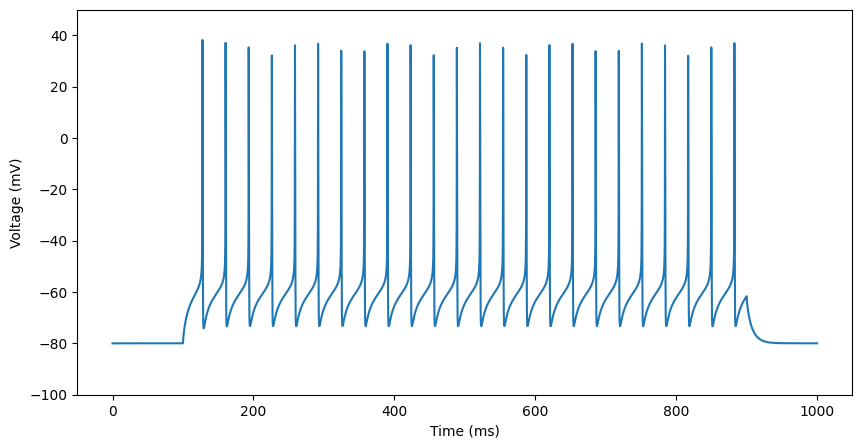

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, v)
ax.set_ylim(-100, 50)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (mV)')

In [22]:
import numpy as np
np.save('v_nrn.npy', v)

### Removeing stimuli

In [23]:
print('Point processes before:', cell.soma[0].psection()['point_processes'])
iclamp = None
del iclamp
# garbage collector: we need to delete all references
from gc import collect
collect()
print('Point processes after:', cell.soma[0].psection()['point_processes'])

Point processes before: {'IClamp': {IClamp[0]}}
Point processes after: {}


### Synapses

In [24]:
# Synapse (point process from the MOD file)
syn = h.AMPA(cell.dend[0](0.1)) # synapse at the proximal dendrite (near the soma)

In [25]:
# Spike times (of the pre-synaptic "virtual" neuron)
spike_times = [200, 400, 600, 800] # ms
spike_vec = h.Vector(spike_times)
stim = h.VecStim()
stim.play(spike_vec)

1.0

In [26]:
# Connection (pre-to-post)
con = h.NetCon(stim, syn)
con.weight[0] = 1 # (1)
con.delay = 1 # ms

### Synaptic parameters

In [27]:
syn.tau_rise, syn.tau_decay, syn.e # synaptic parameters: time constants in ms and the reversal potential in mV

(0.1, 2.5, 0.0)

In [28]:
syn.gmax = 0.001 # maximal synaptic conductance in uS

### Simulation 2

In [29]:
run(1000)

Text(0, 0.5, 'Voltage (mV)')

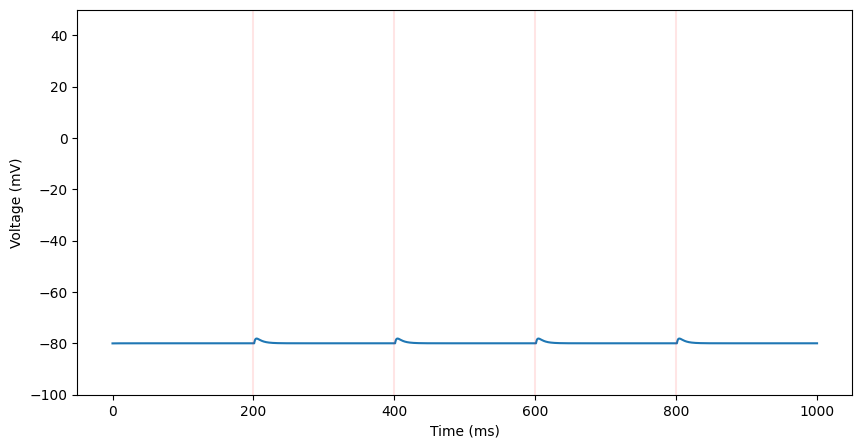

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, v)
ax.set_ylim(-100, 50)
for st in spike_times:
    ax.axvline(st, color='r', alpha=0.1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (mV)')

In [31]:
print(cell.dend[0].psection()['point_processes'])

{'AMPA': {AMPA[0]}}
